In [87]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/Studia-II/Uczenie-Maszynowe/Lista7/Zad5

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import seaborn as sns

In [89]:
RANDOM_STATE = 2137

np.random.seed(RANDOM_STATE)

In [90]:
def run_benchmark(name, naive_func, matrix_func, *args):
    
    start = time.time()
    res_naive = naive_func(*args)
    time_naive = time.time() - start

    start = time.time()
    res_matrix = matrix_func(*args)
    time_matrix = time.time() - start

    is_correct = np.allclose(res_naive, res_matrix, atol=1e-4)
    
    speedup = time_naive / time_matrix if time_matrix > 0 else 0

    return {
        "Operacja": name,
        "Czas pętla [s]": time_naive,
        "Czas macierz [s]": time_matrix,
        "Przyspieszenie": speedup,
        "Poprawność": "OK" if is_correct else "BŁĄD"
    }

In [ ]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def attention_naive(Q, K, V):
    N, d = Q.shape
    output = np.zeros((N, d))
    
    scale = np.sqrt(d)
    
    for i in range(N): 
        scores = np.zeros(N)
        for j in range(N): 
            for k in range(d):
                scores[j] = Q[i][k] * K[j][k] / scale
            
        weights = softmax(scores)
        for j in range(N): 
            output[i] += weights[j] * V[j]
            
    return output

def attention_matrix(Q, K, V):
    N, d = Q.shape
    scores = Q @ K.T / np.sqrt(d)

    return softmax(scores) @ V

In [92]:
def confusion_naive(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    
    for i in range(len(y_true)):
        t = y_true[i]
        p = y_pred[i]
        cm[t, p] += 1
        
    return cm

def confusion_matrix_mul(y_true, y_pred, n_classes):
    Y_true = np.eye(n_classes)[y_true]
    Y_pred = np.eye(n_classes)[y_pred]
    
    return Y_true.T @ Y_pred

In [96]:
def batchnorm_naive(X, gamma, beta, eps=1e-5):
    N, d = X.shape
    out = np.zeros_like(X)
    
    for j in range(d):
        col = X[:, j]
        
        mu = np.mean(col)
        var = np.var(col)
        
        for i in range(N):
            out[i, j] = (X[i, j] - mu) / np.sqrt(var + eps) * gamma[j] + beta[j]
            
    return out

def batchnorm_matrix(X, gamma, beta, eps=1e-5):
    mu = np.mean(X, axis=0)
    var = np.var(X, axis=0)
    return (X - mu) / np.sqrt(var + eps) * gamma + beta

In [94]:
def pagerank_naive(M, d=0.85, max_iter=50):
    n = M.shape[0]
    r = np.ones(n) / n
    teleport = (1 - d) / n * np.ones(n)
    
    for _ in range(max_iter):
        r_new = np.zeros(n)
        
        for i in range(n): 
            sum_val = 0.0
            for j in range(n):      
                sum_val += M[i, j] * r[j]
            r_new[i] = d * sum_val + teleport[i]
            
        r = r_new
        
    return r

def pagerank_matrix(M, d=0.85, max_iter=50):
    n = M.shape[0]
    r = np.ones(n) / n
    teleport = (1 - d) / n * np.ones(n)
    
    for _ in range(max_iter):
        r = d * (M @ r) + teleport
    return r

In [97]:
results = []

print(">> Testuję Attention...")
seq_lens = [64, 256, 512]
d_model = 64
for N in seq_lens:
    Q = np.random.randn(N, d_model)
    K = np.random.randn(N, d_model)
    V = np.random.randn(N, d_model)
    results.append(run_benchmark(f"Attention (N={N})", attention_naive, attention_matrix, Q, K, V))

print(">> Testuję Confusion Matrix...")
cm_scenarios = [(10_000, 10), (100_000, 50)]
for n_samples, n_classes in cm_scenarios:
    y_true = np.random.randint(0, n_classes, n_samples)
    y_pred = np.random.randint(0, n_classes, n_samples)
    results.append(run_benchmark(f"ConfMat (N={n_samples})", confusion_naive, confusion_matrix_mul, y_true, y_pred, n_classes))

print(">> Testuję Batch Norm...")
bn_features = [512, 1024, 2048]
batch_size = 128
for D in bn_features:
    X = np.random.randn(batch_size, D)
    gamma = np.ones(D)
    beta = np.zeros(D)
    results.append(run_benchmark(f"BatchNorm (D={D})", batchnorm_naive, batchnorm_matrix, X, gamma, beta))

print(">> Testuję PageRank...")
pr_nodes = [100, 200, 300]
for n in pr_nodes:
    M_raw = np.random.rand(n, n)
    M = M_raw / M_raw.sum(axis=0)
    results.append(run_benchmark(f"PageRank (N={n})", pagerank_naive, pagerank_matrix, M))

>> Testuję Attention...
>> Testuję Confusion Matrix...
>> Testuję Batch Norm...
>> Testuję PageRank...


,Operacja,Czas pętla [s],Czas macierz [s],Przyspieszenie,Poprawność
0,Attention (N=64),0.07390,0.00065,113.94853,BŁĄD
1,Attention (N=256),1.11778,0.00241,464.55767,BŁĄD
2,Attention (N=512),4.45919,0.00584,763.95642,BŁĄD
3,ConfMat (N=10000),0.00253,0.00142,1.78397,OK
4,ConfMat (N=100000),0.02295,0.03328,0.68971,OK
5,BatchNorm (D=512),0.06942,0.00114,60.94265,OK
6,BatchNorm (D=1024),0.12654,0.00116,108.89023,OK
7,BatchNorm (D=2048),0.21958,0.00229,95.69836,OK
8,PageRank (N=100),0.07168,0.00031,228.10091,OK
9,PageRank (N=200),0.27338,0.00160,170.62887,OK


/tmp/ipykernel_31800/287893609.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Przyspieszenie", y="Operacja", data=df_plot, palette="viridis")


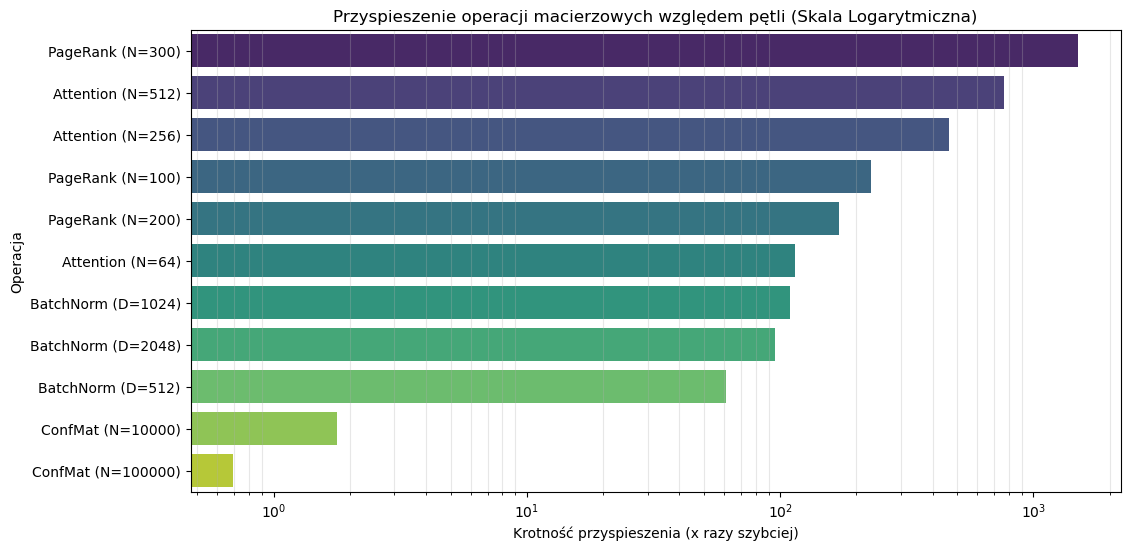

In [98]:
df_results = pd.DataFrame(results)

pd.options.display.float_format = '{:.5f}'.format
display(df_results)

plt.figure(figsize=(12, 6))
df_plot = df_results.sort_values("Przyspieszenie", ascending=False)

sns.barplot(x="Przyspieszenie", y="Operacja", data=df_plot, palette="viridis")
plt.xscale("log")
plt.title("Przyspieszenie operacji macierzowych względem pętli (Skala Logarytmiczna)")
plt.xlabel("Krotność przyspieszenia (x razy szybciej)")
plt.grid(axis="x", which="minor", alpha=0.3)
plt.show()